### 7DOF Plots Overlay

In [36]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plot_results import save_trajectory, post_processing, KittiEvalOdom, align_trajectory_7dof, recover_trajectory_and_poses

gt_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/data/poses"
pred_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/plotdir_npy"
output_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/output_dir"

GOOGLE_BLUE = "#4285F4"
GOOGLE_ORANGE = "#FBBC04"
MODEL_COLORS = ["#FBBC04", "#FFA07A", "#8B9467", "#4CAF50", "#03A9F4", "#9C27B0"]

sequences = [1, 4, 10]

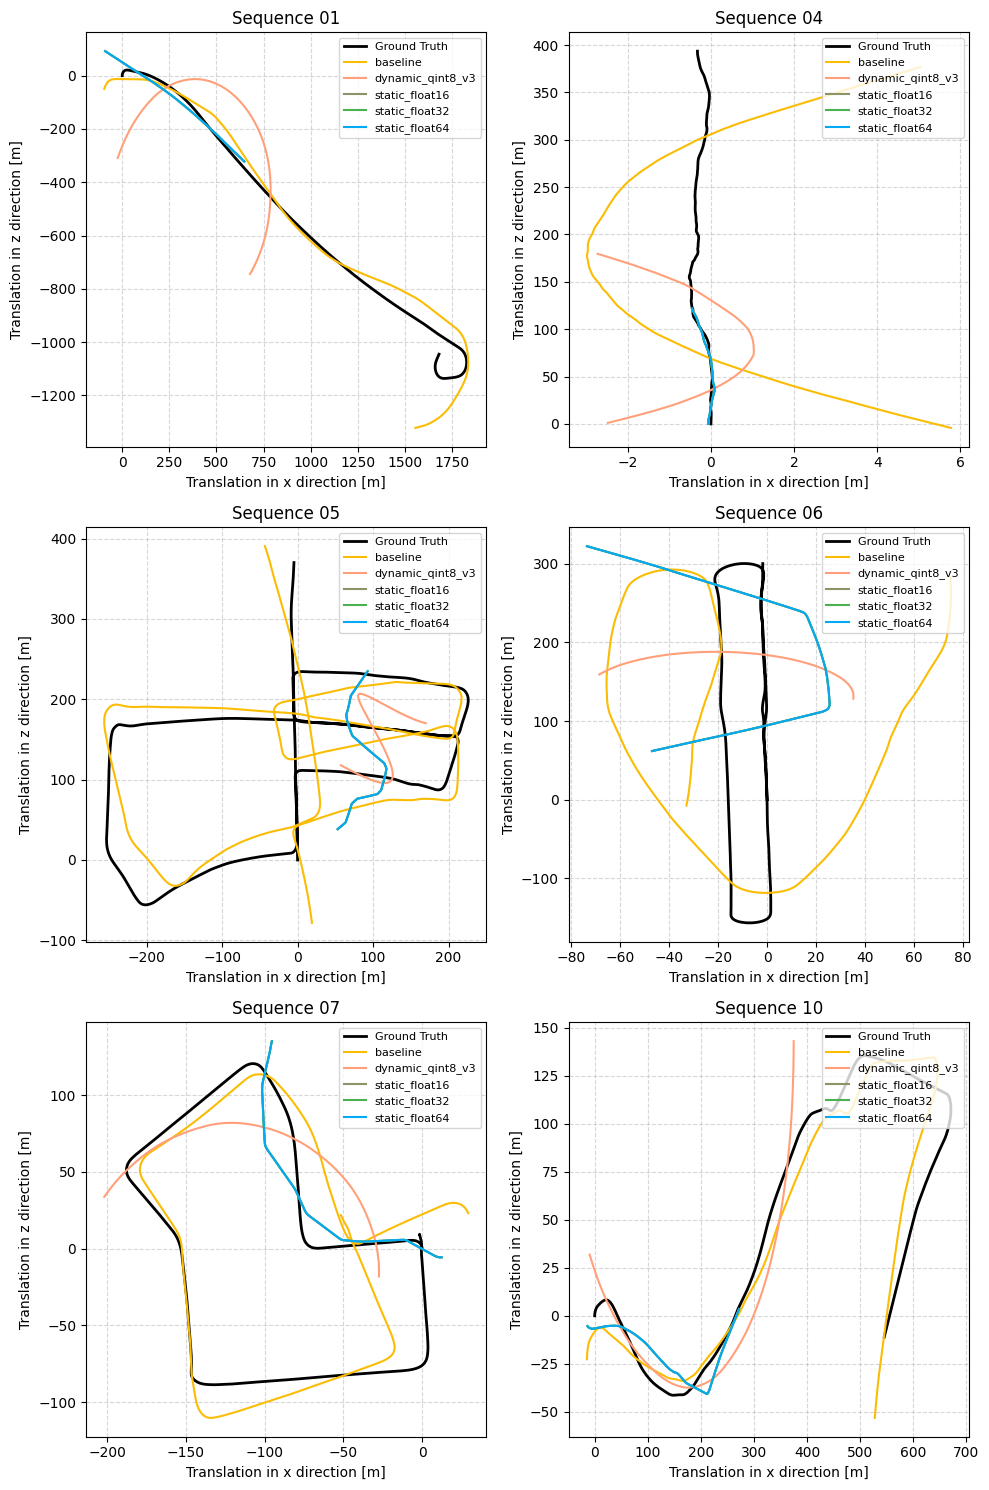

Metrics saved to vo_metrics.csv
Trajectory plots saved to trajectory_grid.png


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
Sequence,01,01,01,01,01,04,04,04,04,04,...,07,07,07,07,07,10,10,10,10,10
Model,baseline,dynamic_qint8_v3,static_float16,static_float32,static_float64,baseline,dynamic_qint8_v3,static_float16,static_float32,static_float64,...,baseline,dynamic_qint8_v3,static_float16,static_float32,static_float64,baseline,dynamic_qint8_v3,static_float16,static_float32,static_float64
Trans.Error (%),23.671383,46.30439,44.739565,44.739565,44.744829,9.035017,15.878588,1.84022,1.84022,1.840367,...,13.998317,67.503104,70.140157,70.140157,70.143647,14.913271,68.49866,62.168846,62.168846,62.170513
Rot.Error (deg/100m),5.855448,13.197211,11.122862,11.122862,11.124697,4.874236,20.186913,1.501277,1.501277,1.500385,...,7.440356,76.252802,73.113605,73.113605,73.119984,4.381155,42.760308,46.748457,46.748457,46.751108
ATE (m),101.698929,173.614253,42.654587,42.654587,42.653157,6.004528,4.036532,0.702883,0.702883,0.703123,...,23.160623,28.287631,14.045813,14.045813,14.04659,23.140533,18.482587,10.735109,10.735109,10.732957
RPE Trans. (m),0.541513,0.457253,0.671506,0.671506,0.671462,0.141439,0.04105,0.111123,0.111123,0.111138,...,0.123322,0.280648,0.247147,0.247147,0.247147,0.159156,0.112681,0.201398,0.201398,0.201384
RPE Rot. (deg),0.310364,0.484029,0.531681,0.531681,0.531706,0.174285,0.32289,0.161676,0.161676,0.161672,...,0.281594,1.036911,1.313885,1.313885,1.313945,0.321746,0.650643,0.832707,0.832707,0.832742


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from kitti_odometry import KittiEvalOdom

# Initialize metrics collection and plot grid
all_metrics = []
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
models = ["baseline", "dynamic_qint8_v3", "static_float16", "static_float32", "static_float64"]  # Define your models here
# models = ["baseline", "random_structured", "global_unstructured_v2", "l1_structured", "sensitivity", "kmeans"]
# models = ["baseline", "global_unstructured", "global_unstructured_v2"]
# models = ["baseline", "dynamic_qint8", "dynamic_qint8_v2", "dynamic_qint8_v3"]

# Main processing loop
for idx, sequence in enumerate([1, 4, 5, 6, 7, 10]):
    seq = str(sequence).zfill(2)
    kitti_eval = KittiEvalOdom()
    
    # Load ground truth data
    gt_path = os.path.join("/Users/epheriami/Downloads/4B/Code/SYDE 673/P/data/poses", f"{seq}.txt")
    gt_poses = kitti_eval.load_poses_from_txt(gt_path)
    gt_poses_list = [gt_poses[i] for i in sorted(gt_poses.keys())]
    
    # Set up subplot
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    gt_trajectory = np.array([pose[:3, 3] for pose in gt_poses_list])
    ax.plot(gt_trajectory[:, 0], gt_trajectory[:, 2], color="black", linewidth=2, label="Ground Truth")

    # Process each model
    for model in models:
        # Load and align predictions
        pred_path = os.path.join(pred_dir, model, f"pred_poses_{seq}.npy")
        pred_poses = np.load(pred_path)
        processed = post_processing(pred_poses, {"window_size": 3})
        pred_poses, _ = recover_trajectory_and_poses(processed)
        aligned_pred_poses = align_trajectory_7dof(pred_poses, gt_poses_list)
        
        # Metric computation
        common_length = min(len(aligned_pred_poses), len(gt_poses_list))
        poses_result = {i: aligned_pred_poses[i] for i in range(common_length)}
        poses_gt = {i: gt_poses_list[i] for i in range(common_length)}
        
        seq_err = kitti_eval.calc_sequence_errors(poses_gt, poses_result)
        avg_t_err, avg_r_err = kitti_eval.compute_overall_err(seq_err)
        ate = kitti_eval.compute_ATE(poses_gt, poses_result)
        rpe_trans, rpe_rot = kitti_eval.compute_RPE(poses_gt, poses_result)
        
        # Store metrics
        all_metrics.append({
            'Sequence': seq,
            'Model': model,
            'Trans.Error (%)': avg_t_err * 100,
            'Rot.Error (deg/100m)': avg_r_err / np.pi * 180 * 100,
            'ATE (m)': ate,
            'RPE Trans. (m)': rpe_trans,
            'RPE Rot. (deg)': rpe_rot * 180 / np.pi
        })

        # Plotting (original logic preserved)
        pred_traj = np.array([pose[:3, 3] for pose in aligned_pred_poses])
        ax.plot(pred_traj[:, 0], pred_traj[:, 2], 
                color=MODEL_COLORS[models.index(model)], 
                label=model)

    # Subplot configuration
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(f"Sequence {seq}", fontsize=12)
    ax.set_xlabel("Translation in x direction [m]", fontsize=10)
    ax.set_ylabel("Translation in z direction [m]", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

# Save outputs
plt.tight_layout()
# plt.savefig("trajectory_grid.png")
# plt.close()
plt.show()

# Create and save metrics dataframe
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv("vo_metrics.csv", index=False)
print("Metrics saved to vo_metrics.csv")
print("Trajectory plots saved to trajectory_grid.png")

metrics_df.T